In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = sns.load_dataset('titanic')

print("Dataset loaded successfully!")
print(f"Dataset Source: Seaborn Built-in Repository (Titanic Dataset)")
print(f"Number of Samples (Rows): {df.shape[0]}")
print(f"Number of Features (Columns): {df.shape[1]}")
print(f"Target Variable: 'survived'")
print(f"Type of Problem: Binary Classification (Predicting 0 = No, 1 = Yes)")

Dataset loaded successfully!
Dataset Source: Seaborn Built-in Repository (Titanic Dataset)
Number of Samples (Rows): 891
Number of Features (Columns): 15
Target Variable: 'survived'
Type of Problem: Binary Classification (Predicting 0 = No, 1 = Yes)


In [2]:
# First 5 records
print("--- First 5 Records ---")
display(df.head())

# Last 5 records
print("\n--- Last 5 Records ---")
display(df.tail())

# Dataset Info (Data types and non-null counts)
print("\n--- Dataset Information ---")
df.info()

# Missing values count per column
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

# Duplicate records
print("\n--- Total Duplicate Records ---")
print(f"Duplicates: {df.duplicated().sum()}")

# Summary descriptive statistics
print("\n--- Descriptive Statistics ---")
display(df.describe())

--- First 5 Records ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Last 5 Records ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True



--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- Missing Values Per Column ---
survived       

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


C:\Users\Ansari\AppData\Local\Temp\ipykernel_10924\2828626301.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pclass', y='fare', data=df, palette='Set2')


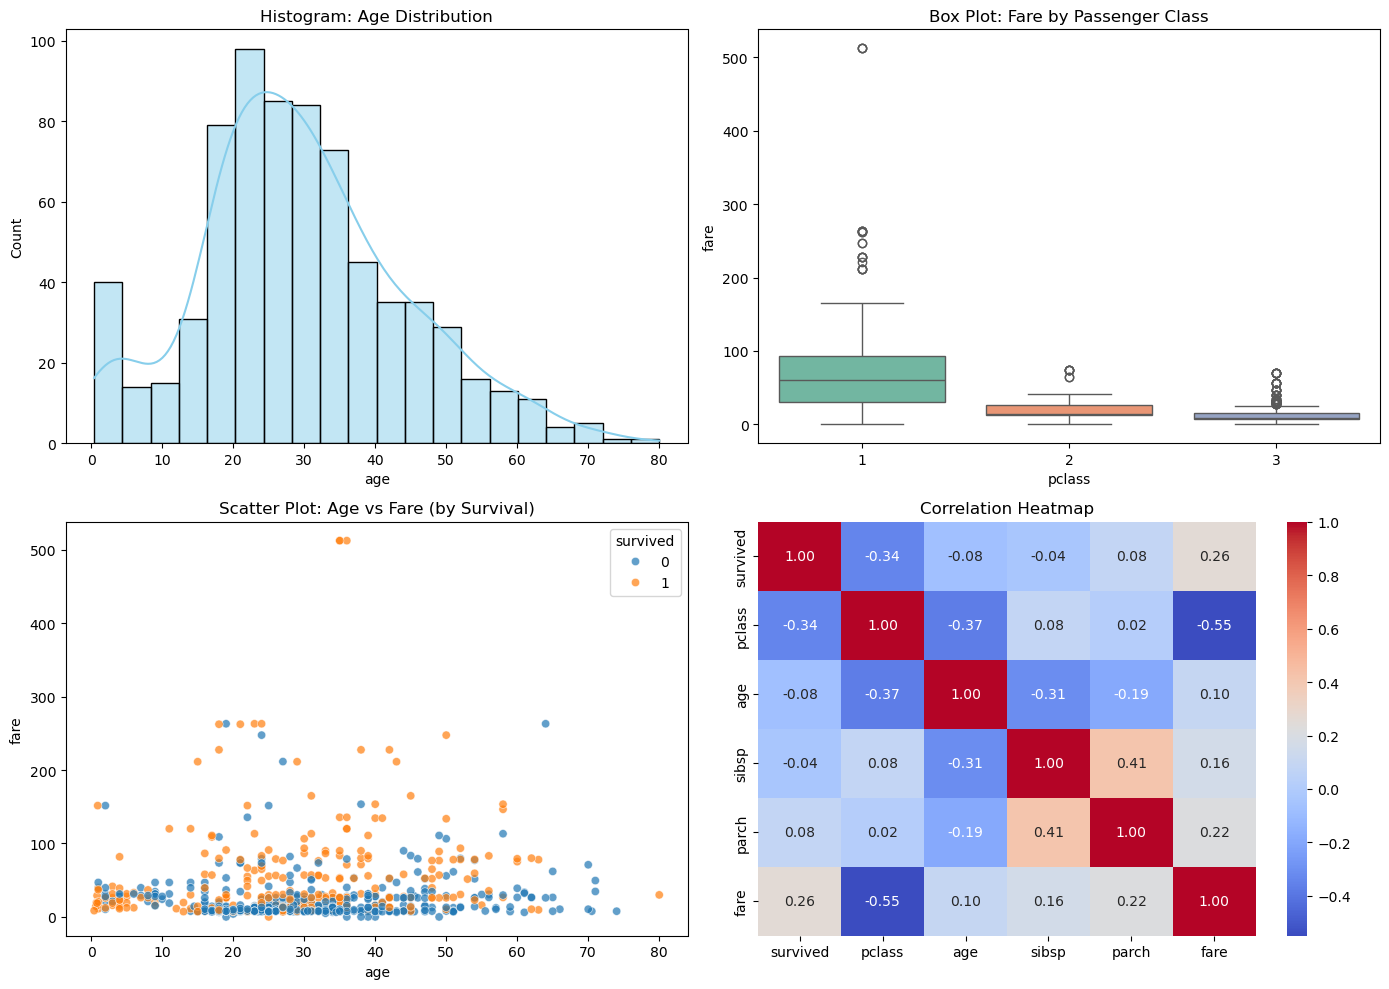

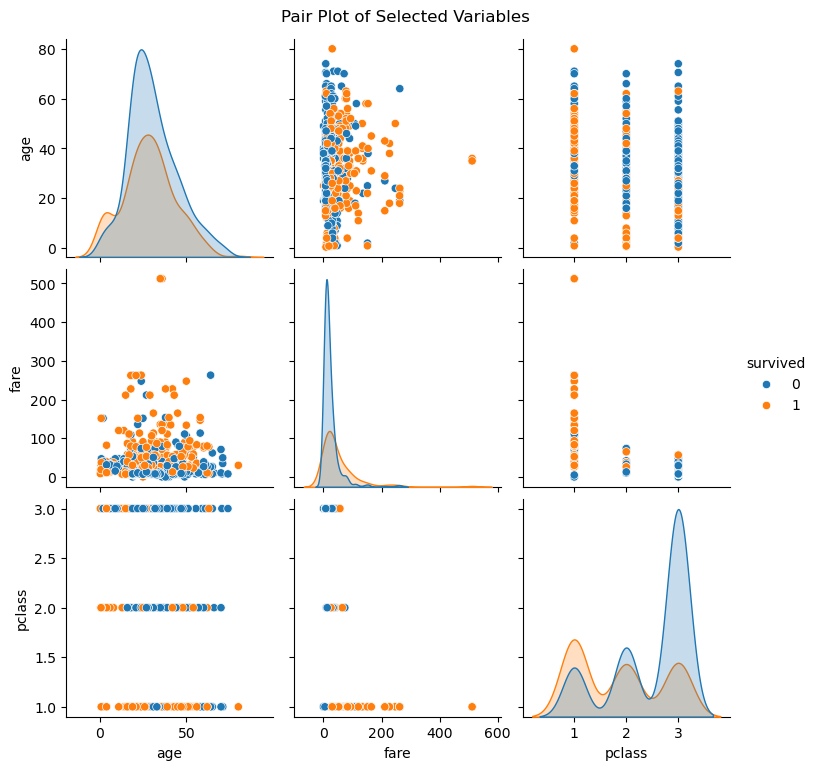

In [3]:
plt.figure(figsize=(14, 10))

# 1. Histogram: Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(df['age'].dropna(), kde=True, color='skyblue')
plt.title('Histogram: Age Distribution')

# 2. Box Plot: Fare across Passenger Classes
plt.subplot(2, 2, 2)
sns.boxplot(x='pclass', y='fare', data=df, palette='Set2')
plt.title('Box Plot: Fare by Passenger Class')

# 3. Scatter Plot: Age vs Fare colored by Survival
plt.subplot(2, 2, 3)
sns.scatterplot(x='age', y='fare', hue='survived', data=df, alpha=0.7)
plt.title('Scatter Plot: Age vs Fare (by Survival)')

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

# 5. Pair Plot for selected variables
sns.pairplot(df[['age', 'fare', 'pclass', 'survived']].dropna(), hue='survived')
plt.suptitle('Pair Plot of Selected Variables', y=1.02)
plt.show()

In [4]:
age_data = df['age'].dropna()

q75, q25 = np.percentile(age_data, [75, 25])

stats_data = {
    'Metric': [
        'Mean', 'Median', 'Mode', 'Variance', 
        'Standard Deviation', 'Range', 'Interquartile Range (IQR)', 
        'Skewness', 'Kurtosis'
    ],
    'Value (Age Column)': [
        age_data.mean(),
        age_data.median(),
        age_data.mode()[0],
        age_data.var(),
        age_data.std(),
        age_data.max() - age_data.min(),
        q75 - q25,
        age_data.skew(),
        age_data.kurtosis()
    ]
}

stats_df = pd.DataFrame(stats_data)
display(stats_df)

,Metric,Value (Age Column)
0,Mean,29.699118
1,Median,28.000000
2,Mode,24.000000
3,Variance,211.019125
4,Standard Deviation,14.526497
5,Range,79.580000
6,Interquartile Range (IQR),17.875000
7,Skewness,0.389108
8,Kurtosis,0.178274


In [5]:
from sklearn.preprocessing import StandardScaler

# Work on a fresh copy
df_clean = df.copy()

# 1. Handle Missing Values
df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
df_clean['embarked'].fillna(df_clean['embarked'].mode()[0], inplace=True)
df_clean.drop(columns=['deck'], inplace=True, errors='ignore')  # Dropped due to ~77% missing values

# 2. Treat Outliers in 'fare' using IQR Capping
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_clean['fare'] = np.where(df_clean['fare'] > upper_bound, upper_bound, df_clean['fare'])

# 3. Encode Categorical Variables
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

# 4. Standardise Numerical Features
scaler = StandardScaler()
df_clean[['age', 'fare']] = scaler.fit_transform(df_clean[['age', 'fare']])

print("Data Preprocessing Completed Successfully!")
display(df_clean.head())

Data Preprocessing Completed Successfully!


C:\Users\Ansari\AppData\Local\Temp\ipykernel_10924\1273730092.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['age'].fillna(df_clean['age'].median(), inplace=True)
C:\Users\Ansari\AppData\Local\Temp\ipykernel_10924\1273730092.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,-0.565736,1,0,-0.820552,Third,man,True,Southampton,no,False,True,False,True
1,1,1,0.663861,1,0,2.031623,First,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,-0.258337,0,0,-0.787578,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,0.433312,1,0,1.419297,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0.433312,0,0,-0.781471,Third,man,True,Southampton,no,True,True,False,True


In [6]:
from sklearn.preprocessing import StandardScaler

# Work on a fresh copy
df_clean = df.copy()

# 1. Handle Missing Values (Updated modern syntax to avoid warnings)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean = df_clean.drop(columns=['deck'], errors='ignore')  # Dropped due to missing values

# 2. Treat Outliers in 'fare' using IQR Capping
Q1 = df_clean['fare'].quantile(0.25)
Q3 = df_clean['fare'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_clean['fare'] = np.where(df_clean['fare'] > upper_bound, upper_bound, df_clean['fare'])

# 3. Encode Categorical Variables
df_clean = pd.get_dummies(df_clean, columns=['sex', 'embarked'], drop_first=True)

# 4. Standardise Numerical Features
scaler = StandardScaler()
df_clean[['age', 'fare']] = scaler.fit_transform(df_clean[['age', 'fare']])

print("Data Preprocessing Completed Successfully!")
display(df_clean.head())

Data Preprocessing Completed Successfully!


,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,-0.565736,1,0,-0.820552,Third,man,True,Southampton,no,False,True,False,True
1,1,1,0.663861,1,0,2.031623,First,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,-0.258337,0,0,-0.787578,Third,woman,False,Southampton,yes,True,False,False,True
3,1,1,0.433312,1,0,1.419297,First,woman,False,Southampton,yes,False,False,False,True
4,0,3,0.433312,0,0,-0.781471,Third,man,True,Southampton,no,True,True,False,True


In [7]:
from sklearn.model_selection import train_test_split

# 1. Simple Random Sampling
srs_sample = df.sample(n=100, random_state=42)

# 2. Stratified Sampling (Stratified by 'survived')
_, stratified_sample = train_test_split(df, test_size=100, stratify=df['survived'], random_state=42)

# Compare Samples
comparison_df = pd.DataFrame({
    'Dataset': ['Original Dataset', 'Simple Random Sample', 'Stratified Sample'],
    'Survival Rate': [df['survived'].mean(), srs_sample['survived'].mean(), stratified_sample['survived'].mean()],
    'Mean Age': [df['age'].mean(), srs_sample['age'].mean(), stratified_sample['age'].mean()]
})

display(comparison_df)

,Dataset,Survival Rate,Mean Age
0,Original Dataset,0.383838,29.699118
1,Simple Random Sample,0.400000,29.608434
2,Stratified Sample,0.380000,29.712500


In [8]:
# Part G: Conclusion

## Major Insights Obtained:
1. **Class Difference**: Passengers in 1st class had a significantly higher survival rate compared to 3rd class passengers.
2. **Gender Priority**: Female passengers had a markedly higher survival rate compared to male passengers.
3. **Correlation**: Ticket fare showed a positive correlation with survival.

## Data Quality Issues:
- The `deck` column had over 70% missing data and was dropped.
- The `fare` variable had extreme outliers that were capped using the IQR method.

## Suitability for Machine Learning:
- The dataset is well-structured for binary classification models (predicting survival). Following missing value imputation, categorical encoding, and feature scaling, it provides clean inputs for training machine learning models.

---

## AI Ethical Usage Declaration
I declare that this assignment is my original work. Any Generative AI tools (such as ChatGPT, Gemini, GitHub Copilot, or similar) were used only to assist with learning, debugging, or improving code readability. I have independently verified all code, analysis, visualisations, interpretations, and conclusions presented in this notebook. Any external resources or AI assistance used have been appropriately acknowledged.

SyntaxError: invalid decimal literal (1447883670.py, line 4)

# Part G: Conclusion

## Major Insights Obtained:
1. **Class Difference**: Passengers in 1st class had a significantly higher survival rate compared to 3rd class passengers.
2. **Gender Priority**: Female passengers had a markedly higher survival rate compared to male passengers.
3. **Correlation**: Ticket fare showed a positive correlation with survival.

## Data Quality Issues:
- The `deck` column had over 70% missing data and was dropped.
- The `fare` variable had extreme outliers that were capped using the IQR method.

## Suitability for Machine Learning:
- The dataset is well-structured for binary classification models (predicting survival). Following missing value imputation, categorical encoding, and feature scaling, it provides clean inputs for training machine learning models.

---

## AI Ethical Usage Declaration
I declare that this assignment is my original work. Any Generative AI tools (such as ChatGPT, Gemini, GitHub Copilot, or similar) were used only to assist with learning, debugging, or improving code readability. I have independently verified all code, analysis, visualisations, interpretations, and conclusions presented in this notebook. Any external resources or AI assistance used have been appropriately acknowledged.

In [9]:
import os
print(os.getcwd())

C:\Users\Ansari
